# 06 — Concatenate All Extracted Features and Train One Classifier

This notebook horizontally concatenates all feature sets produced by notebook 03 and trains one classifier on the combined feature vector.

It is designed for large `.npy` datasets. Concatenation and scaling are done chunk-by-chunk with memory-mapped `.npy` files.


In [48]:
from pathlib import Path
import copy
import pickle
import json

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"..")
OUTPUT_DIR = PROJECT_ROOT / "output"

SPLIT_DIR = OUTPUT_DIR / "splits"
FEATURE_DIR = OUTPUT_DIR / "features"

CONCAT_FEATURE_DIR = OUTPUT_DIR / "concat_all_features_1"
RESULTS_DIR = OUTPUT_DIR / "concat_all_features_results_1"

CONCAT_FEATURE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
PATIENCE = 10
RANDOM_SEED = 42

CHUNK_SIZE = 2048
SCALER_CHUNK_SIZE = 4096

OVERWRITE_CONCAT_FEATURES = False
OVERWRITE_SCALED_FEATURES = False

SAVE_ALL_SPLIT_EMBEDDINGS = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Device:", device)
print("Feature directory:", FEATURE_DIR)
print("Concat feature directory:", CONCAT_FEATURE_DIR)
print("Results directory:", RESULTS_DIR)


Device: cuda
Feature directory: ..\output\features
Concat feature directory: ..\output\concat_all_features_1
Results directory: ..\output\concat_all_features_results_1


In [49]:
class_names = np.load(SPLIT_DIR / "class_names.npy", allow_pickle=True)
class_names = np.asarray(class_names).astype(str)

y_train_raw = np.load(SPLIT_DIR / "y_train_idx.npy", allow_pickle=True)
y_val_raw = np.load(SPLIT_DIR / "y_val_idx.npy", allow_pickle=True)
y_test_raw = np.load(SPLIT_DIR / "y_test_idx.npy", allow_pickle=True)

class_to_idx = {name: idx for idx, name in enumerate(class_names)}


def labels_to_int(labels, split_name):
    labels = np.asarray(labels)

    if np.issubdtype(labels.dtype, np.integer):
        return labels.astype(np.int64)

    labels_str = labels.astype(str)

    missing = sorted(set(labels_str) - set(class_to_idx))
    if missing:
        raise ValueError(
            f"{split_name} contains labels not present in class_names.npy: {missing[:20]}"
        )

    return np.asarray([class_to_idx[label] for label in labels_str], dtype=np.int64)


def labels_to_names(labels):
    labels = np.asarray(labels)

    if np.issubdtype(labels.dtype, np.integer):
        return np.asarray([class_names[int(i)] for i in labels], dtype=str)

    return labels.astype(str)


y_train = labels_to_int(y_train_raw, "y_train_idx.npy")
y_val = labels_to_int(y_val_raw, "y_val_idx.npy")
y_test = labels_to_int(y_test_raw, "y_test_idx.npy")

y_train_names = labels_to_names(y_train_raw)
y_val_names = labels_to_names(y_val_raw)
y_test_names = labels_to_names(y_test_raw)

num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Train:", y_train.shape, y_train.dtype)
print("Val:", y_val.shape, y_val.dtype)
print("Test:", y_test.shape, y_test.dtype)

print("\nExample mapping:")
for i in range(min(10, len(y_train))):
    print(y_train_names[i], "->", y_train[i])


Number of classes: 32
Train: (82434,) int64
Val: (27478,) int64
Test: (27478,) int64

Example mapping:
Triclosan_05x -> 29
Mecillinam_05x -> 13
Nisin_5x -> 20
Kanamycin_2x -> 12
Kanamycin_05x -> 11
PMB_05x -> 23
Mecillinam_05x -> 13
Triclosan_05x -> 29
Triclosan_2x -> 30
PMB_05x -> 23


In [50]:
feature_folders = []

for folder in sorted(FEATURE_DIR.iterdir()):
    if not folder.is_dir():
        continue

    required_files = [
        folder / "train_features.npy",
        folder / "val_features.npy",
        folder / "test_features.npy",
    ]

    if all(path.exists() for path in required_files):
        feature_folders.append(folder)

if not feature_folders:
    raise FileNotFoundError(
        f"No valid feature folders found in {FEATURE_DIR}. "
        "Run 03_extract_pretrained_features_npy.ipynb first."
    )

print("Detected feature folders:")
for folder in feature_folders:
    print("-", folder.name)

rows = []
for folder in feature_folders:
    train_shape = np.load(folder / "train_features.npy", mmap_mode="r").shape
    val_shape = np.load(folder / "val_features.npy", mmap_mode="r").shape
    test_shape = np.load(folder / "test_features.npy", mmap_mode="r").shape

    rows.append({
        "feature_name": folder.name,
        "train_shape": train_shape,
        "val_shape": val_shape,
        "test_shape": test_shape,
        "feature_dim": train_shape[1],
    })

shape_df = pd.DataFrame(rows)
display(shape_df)

total_feature_dim = int(shape_df["feature_dim"].sum())
print("Total concatenated feature dimension:", total_feature_dim)


Detected feature folders:
- cytoimagenet_efficientnetb0
- densenet121
- efficientnet_b0
- mobilenet_v3_large
- resnet50
- vit_b_16


,feature_name,train_shape,val_shape,test_shape,feature_dim
0,cytoimagenet_efficientnetb0,"(82434, 5120)","(27478, 5120)","(27478, 5120)",5120
1,densenet121,"(82434, 4096)","(27478, 4096)","(27478, 4096)",4096
2,efficientnet_b0,"(82434, 5120)","(27478, 5120)","(27478, 5120)",5120
3,mobilenet_v3_large,"(82434, 3840)","(27478, 3840)","(27478, 3840)",3840
4,resnet50,"(82434, 8192)","(27478, 8192)","(27478, 8192)",8192
5,vit_b_16,"(82434, 3072)","(27478, 3072)","(27478, 3072)",3072


Total concatenated feature dimension: 29440


In [51]:
def load_split_arrays(feature_folders, split_name):
    arrays = []
    for folder in feature_folders:
        path = folder / f"{split_name}_features.npy"
        arr = np.load(path, mmap_mode="r")
        arrays.append(arr)
    return arrays


def check_split_arrays(arrays, split_name, expected_n):
    n_samples = arrays[0].shape[0]

    if n_samples != expected_n:
        raise ValueError(
            f"{split_name} feature count mismatch: features have {n_samples}, "
            f"but labels have {expected_n}."
        )

    for i, arr in enumerate(arrays):
        if arr.ndim != 2:
            raise ValueError(
                f"{split_name} array {i} must be 2D, got shape {arr.shape}."
            )

        if arr.shape[0] != n_samples:
            raise ValueError(
                f"{split_name} sample count mismatch. "
                f"Expected {n_samples}, got {arr.shape[0]} in feature index {i}."
            )

    return n_samples, int(sum(arr.shape[1] for arr in arrays))


def concatenate_split_to_memmap(
    feature_folders,
    split_name,
    labels,
    out_file,
    overwrite=False,
    chunk_size=CHUNK_SIZE,
):
    out_file = Path(out_file)

    if out_file.exists() and not overwrite:
        print(f"Using existing concatenated {split_name} file:", out_file)
        return np.load(out_file, mmap_mode="r")

    arrays = load_split_arrays(feature_folders, split_name)
    n_samples, total_dim = check_split_arrays(
        arrays,
        split_name=split_name,
        expected_n=len(labels),
    )

    if out_file.exists():
        out_file.unlink()

    out = np.lib.format.open_memmap(
        out_file,
        mode="w+",
        dtype=np.float32,
        shape=(n_samples, total_dim),
    )

    for start in range(0, n_samples, chunk_size):
        end = min(start + chunk_size, n_samples)

        chunks = [
            np.asarray(arr[start:end], dtype=np.float32)
            for arr in arrays
        ]

        out[start:end] = np.concatenate(chunks, axis=1)

        if end % (chunk_size * 10) == 0 or end == n_samples:
            print(f"  {split_name}: concatenated {end}/{n_samples}")

    out.flush()
    del out

    return np.load(out_file, mmap_mode="r")


In [52]:
X_train_concat = concatenate_split_to_memmap(
    feature_folders,
    split_name="train",
    labels=y_train,
    out_file=CONCAT_FEATURE_DIR / "train_concat_features.npy",
    overwrite=OVERWRITE_CONCAT_FEATURES,
)

X_val_concat = concatenate_split_to_memmap(
    feature_folders,
    split_name="val",
    labels=y_val,
    out_file=CONCAT_FEATURE_DIR / "val_concat_features.npy",
    overwrite=OVERWRITE_CONCAT_FEATURES,
)

X_test_concat = concatenate_split_to_memmap(
    feature_folders,
    split_name="test",
    labels=y_test,
    out_file=CONCAT_FEATURE_DIR / "test_concat_features.npy",
    overwrite=OVERWRITE_CONCAT_FEATURES,
)

print("Concatenated feature shapes:")
print("Train:", X_train_concat.shape)
print("Val:", X_val_concat.shape)
print("Test:", X_test_concat.shape)


Using existing concatenated train file: ..\output\concat_all_features_1\train_concat_features.npy
Using existing concatenated val file: ..\output\concat_all_features_1\val_concat_features.npy
Using existing concatenated test file: ..\output\concat_all_features_1\test_concat_features.npy
Concatenated feature shapes:
Train: (82434, 29440)
Val: (27478, 29440)
Test: (27478, 29440)


In [53]:
def iter_feature_chunks(X, chunk_size=SCALER_CHUNK_SIZE):
    for start in range(0, len(X), chunk_size):
        end = min(start + chunk_size, len(X))
        yield start, end, np.asarray(X[start:end], dtype=np.float32)


def fit_scaler_chunked(X_train_raw):
    scaler = StandardScaler()

    for start, end, chunk in iter_feature_chunks(X_train_raw):
        scaler.partial_fit(chunk)

        if end % (SCALER_CHUNK_SIZE * 10) == 0 or end == len(X_train_raw):
            print(f"  scaler fitted on {end}/{len(X_train_raw)} samples")

    return scaler


def transform_to_memmap(X_raw, scaler, out_file, overwrite=False):
    out_file = Path(out_file)

    if out_file.exists() and not overwrite:
        print("Using existing scaled file:", out_file)
        return np.load(out_file, mmap_mode="r")

    if out_file.exists():
        out_file.unlink()

    out = np.lib.format.open_memmap(
        out_file,
        mode="w+",
        dtype=np.float32,
        shape=X_raw.shape,
    )

    for start, end, chunk in iter_feature_chunks(X_raw):
        out[start:end] = scaler.transform(chunk).astype(np.float32)

        if end % (SCALER_CHUNK_SIZE * 10) == 0 or end == len(X_raw):
            print(f"  transformed {end}/{len(X_raw)} samples")

    out.flush()
    del out

    return np.load(out_file, mmap_mode="r")


In [54]:
scaler = fit_scaler_chunked(X_train_concat)

with open(RESULTS_DIR / "concat_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

X_train_scaled = transform_to_memmap(
    X_train_concat,
    scaler,
    RESULTS_DIR / "train_concat_features_scaled.npy",
    overwrite=OVERWRITE_SCALED_FEATURES,
)

X_val_scaled = transform_to_memmap(
    X_val_concat,
    scaler,
    RESULTS_DIR / "val_concat_features_scaled.npy",
    overwrite=OVERWRITE_SCALED_FEATURES,
)

X_test_scaled = transform_to_memmap(
    X_test_concat,
    scaler,
    RESULTS_DIR / "test_concat_features_scaled.npy",
    overwrite=OVERWRITE_SCALED_FEATURES,
)

print("Scaled feature shapes:")
print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)


  scaler fitted on 40960/82434 samples
  scaler fitted on 81920/82434 samples
  scaler fitted on 82434/82434 samples
Using existing scaled file: ..\output\concat_all_features_results_1\train_concat_features_scaled.npy
Using existing scaled file: ..\output\concat_all_features_results_1\val_concat_features_scaled.npy
Using existing scaled file: ..\output\concat_all_features_results_1\test_concat_features_scaled.npy
Scaled feature shapes:
Train: (82434, 29440)
Val: (27478, 29440)
Test: (27478, 29440)


In [55]:
class FeatureDataset(Dataset):
    def __init__(self, X_features, y_idx):
        self.X = X_features
        self.y = np.asarray(y_idx, dtype=np.int64)

        if len(self.X) != len(self.y):
            raise ValueError(
                f"Feature/label length mismatch: X has {len(self.X)} samples, "
                f"but y has {len(self.y)} labels."
            )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = np.asarray(self.X[idx], dtype=np.float32)
        x = np.ascontiguousarray(x)
        y = int(self.y[idx])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


class ConcatFeatureClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.feature_layers = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(1024, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        embedding = self.feature_layers(x)
        logits = self.classifier(embedding)
        return logits

    def extract_embedding(self, x):
        return self.feature_layers(x)


train_dataset = FeatureDataset(X_train_scaled, y_train)
val_dataset = FeatureDataset(X_val_scaled, y_val)
test_dataset = FeatureDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train_scaled.shape[1]

model = ConcatFeatureClassifier(
    input_dim=input_dim,
    num_classes=num_classes,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(model)
print("Input dimension:", input_dim)


ConcatFeatureClassifier(
  (feature_layers): Sequential(
    (0): Linear(in_features=29440, out_features=1024, bias=True)
    (1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=1024, out_features=256, bias=True)
    (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (classifier): Linear(in_features=128, out_features=32, bias=True)
)
Input dimension: 29440


In [56]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(batch_features)
            loss = criterion(logits, batch_labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch_features.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == batch_labels).sum().item()
            total += batch_labels.size(0)

    return total_loss / total, correct / total


In [57]:
history = []
best_val_acc = -1.0
best_state = None
best_epoch = -1
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = run_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
    )

    val_loss, val_acc = run_one_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
    )

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    }
    history.append(row)

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)

if best_state is not None:
    model.load_state_dict(best_state)

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)


Epoch [01/50] Train Loss: 1.5103 Train Acc: 0.4866 Val Loss: 0.8951 Val Acc: 0.6799
Epoch [02/50] Train Loss: 0.9431 Train Acc: 0.6686 Val Loss: 0.7366 Val Acc: 0.7361
Epoch [03/50] Train Loss: 0.7934 Train Acc: 0.7221 Val Loss: 0.6594 Val Acc: 0.7677
Epoch [04/50] Train Loss: 0.6987 Train Acc: 0.7539 Val Loss: 0.6213 Val Acc: 0.7784
Epoch [05/50] Train Loss: 0.6254 Train Acc: 0.7792 Val Loss: 0.5975 Val Acc: 0.7902
Epoch [06/50] Train Loss: 0.5674 Train Acc: 0.8016 Val Loss: 0.5778 Val Acc: 0.7974
Epoch [07/50] Train Loss: 0.5178 Train Acc: 0.8177 Val Loss: 0.5516 Val Acc: 0.8104
Epoch [08/50] Train Loss: 0.4763 Train Acc: 0.8333 Val Loss: 0.5453 Val Acc: 0.8107
Epoch [09/50] Train Loss: 0.4389 Train Acc: 0.8451 Val Loss: 0.5313 Val Acc: 0.8191
Epoch [10/50] Train Loss: 0.4109 Train Acc: 0.8546 Val Loss: 0.5356 Val Acc: 0.8220
Epoch [11/50] Train Loss: 0.3811 Train Acc: 0.8658 Val Loss: 0.5258 Val Acc: 0.8237
Epoch [12/50] Train Loss: 0.3568 Train Acc: 0.8751 Val Loss: 0.5370 Val Acc:

In [58]:
def collect_embeddings_predictions(model, loader, split_name, save_dir):
    model.eval()

    save_dir = Path(save_dir)
    embeddings_path = save_dir / f"{split_name}_concat_classifier_embeddings.npy"
    logits_path = save_dir / f"{split_name}_concat_classifier_logits.npy"

    embedding_memmap = None
    logits_memmap = None

    all_preds = []
    all_labels = []
    write_start = 0

    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features = batch_features.to(device)

            embeddings = model.extract_embedding(batch_features)
            logits = model.classifier(embeddings)

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            labels = batch_labels.numpy()

            embeddings = embeddings.cpu().numpy().astype(np.float32)
            logits = logits.cpu().numpy().astype(np.float32)

            if embedding_memmap is None:
                if embeddings_path.exists():
                    embeddings_path.unlink()
                if logits_path.exists():
                    logits_path.unlink()

                embedding_memmap = np.lib.format.open_memmap(
                    embeddings_path,
                    mode="w+",
                    dtype=np.float32,
                    shape=(len(loader.dataset), embeddings.shape[1]),
                )

                logits_memmap = np.lib.format.open_memmap(
                    logits_path,
                    mode="w+",
                    dtype=np.float32,
                    shape=(len(loader.dataset), logits.shape[1]),
                )

            write_end = write_start + embeddings.shape[0]
            embedding_memmap[write_start:write_end] = embeddings
            logits_memmap[write_start:write_end] = logits
            write_start = write_end

            all_preds.extend(preds)
            all_labels.extend(labels)

    if embedding_memmap is not None:
        embedding_memmap.flush()
        del embedding_memmap

    if logits_memmap is not None:
        logits_memmap.flush()
        del logits_memmap

    pred_idx = np.asarray(all_preds, dtype=np.int64)
    true_idx = np.asarray(all_labels, dtype=np.int64)

    pred_names = np.asarray([class_names[i] for i in pred_idx])
    true_names = np.asarray([class_names[i] for i in true_idx])

    np.save(save_dir / f"{split_name}_concat_predictions_idx.npy", pred_idx)
    np.save(save_dir / f"{split_name}_concat_predictions_names.npy", pred_names)
    np.save(save_dir / f"{split_name}_concat_true_idx.npy", true_idx)
    np.save(save_dir / f"{split_name}_concat_true_names.npy", true_names)

    return pred_idx, true_idx


In [59]:
if SAVE_ALL_SPLIT_EMBEDDINGS:
    train_preds, train_labels = collect_embeddings_predictions(
        model,
        train_eval_loader,
        split_name="train",
        save_dir=RESULTS_DIR,
    )

    val_preds, val_labels = collect_embeddings_predictions(
        model,
        val_loader,
        split_name="val",
        save_dir=RESULTS_DIR,
    )

test_preds, test_labels = collect_embeddings_predictions(
    model,
    test_loader,
    split_name="test",
    save_dir=RESULTS_DIR,
)

test_acc = accuracy_score(test_labels, test_preds)
macro_f1 = f1_score(test_labels, test_preds, average="macro", zero_division=0)
weighted_f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)

report_text = classification_report(
    test_labels,
    test_preds,
    labels=np.arange(num_classes),
    target_names=class_names,
    zero_division=0,
)

cm = confusion_matrix(
    test_labels,
    test_preds,
    labels=np.arange(num_classes),
)

np.save(RESULTS_DIR / "concat_confusion_matrix.npy", cm)

with open(RESULTS_DIR / "concat_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

summary = {
    "feature_name": "concat_all_features",
    "input_dim": int(input_dim),
    "num_classes": int(num_classes),
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "test_acc": float(test_acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "feature_folders": [folder.name for folder in feature_folders],
}

pd.DataFrame([summary]).to_csv(RESULTS_DIR / "concat_summary.csv", index=False)

with open(RESULTS_DIR / "concat_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

torch.save(
    {
        "feature_name": "concat_all_features",
        "input_dim": input_dim,
        "num_classes": num_classes,
        "class_names": class_names.tolist(),
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "feature_folders": [folder.name for folder in feature_folders],
        "model_state_dict": model.state_dict(),
    },
    RESULTS_DIR / "best_concat_classifier.pt",
)

print("\nConcat feature test results")
print("=" * 80)
print("Input dimension:", input_dim)
print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)
print("Test accuracy:", test_acc)
print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)
print("\nClassification report:")
print(report_text)

display(pd.DataFrame([summary]))



Concat feature test results
Input dimension: 29440
Best epoch: 37
Best validation accuracy: 0.8345949486862217
Test accuracy: 0.8361962297110416
Macro F1: 0.8557434873063644
Weighted F1: 0.8367794173214018

Classification report:
                     precision    recall  f1-score   support

            A22_05x       0.82      0.80      0.81      1305
             A22_2x       0.78      0.70      0.74      1193
     Ampicillin_05x       0.83      0.81      0.82       372
      Ampicillin_2x       0.86      0.82      0.84       381
              Blank       0.00      0.00      0.00         0
Chloramphenicol_05x       0.85      0.76      0.80       361
 Chloramphenicol_2x       0.79      0.87      0.83       460
            Control       0.93      0.95      0.94      2263
     Gramacidin_05x       0.91      0.82      0.86      1247
      Gramacidin_2x       0.96      0.92      0.94       336
      Gramacidin_5x       0.99      0.93      0.96       295
      Kanamycin_05x       0.71      

,feature_name,input_dim,num_classes,best_epoch,best_val_acc,test_acc,macro_f1,weighted_f1,feature_folders
0,concat_all_features,29440,32,37,0.834595,0.836196,0.855743,0.836779,"[cytoimagenet_efficientnetb0, densenet121, eff..."


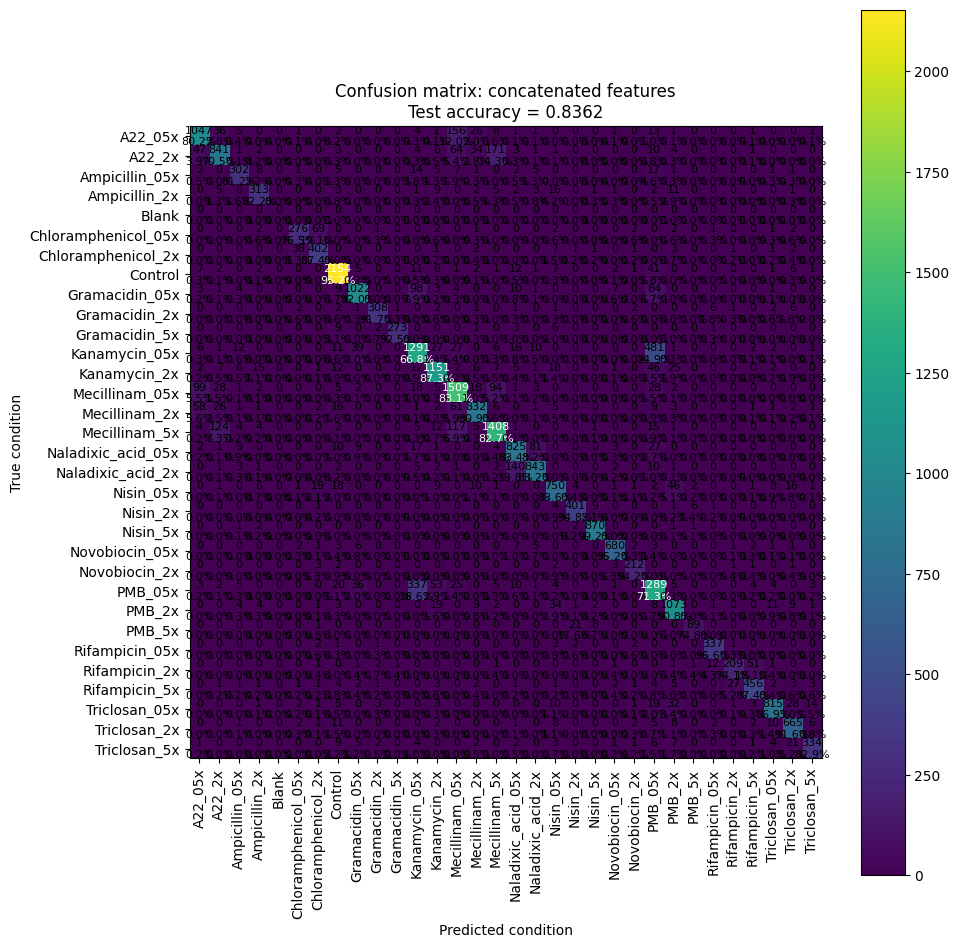

In [60]:
plt.figure(figsize=(10, 10))
plt.imshow(cm)

plt.title(
    f"Confusion matrix: concatenated features\n"
    f"Test accuracy = {test_acc:.4f}"
)

plt.xlabel("Predicted condition")
plt.ylabel("True condition")
plt.xticks(range(num_classes), class_names, rotation=90)
plt.yticks(range(num_classes), class_names)
plt.colorbar()

row_sums = cm.sum(axis=1, keepdims=True)
cm_percent = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0,
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f"{cm[i, j]}\n{cm_percent[i, j] * 100:.1f}%"

        plt.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig(RESULTS_DIR / "concat_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()


UMAP input shape: (5000, 128)
Number of labels: 31
Applied StandardScaler before UMAP.
Before removing outliers: (5000, 128)
After removing outliers: (4750, 128)
Removed: 250


d:\Haohuan\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


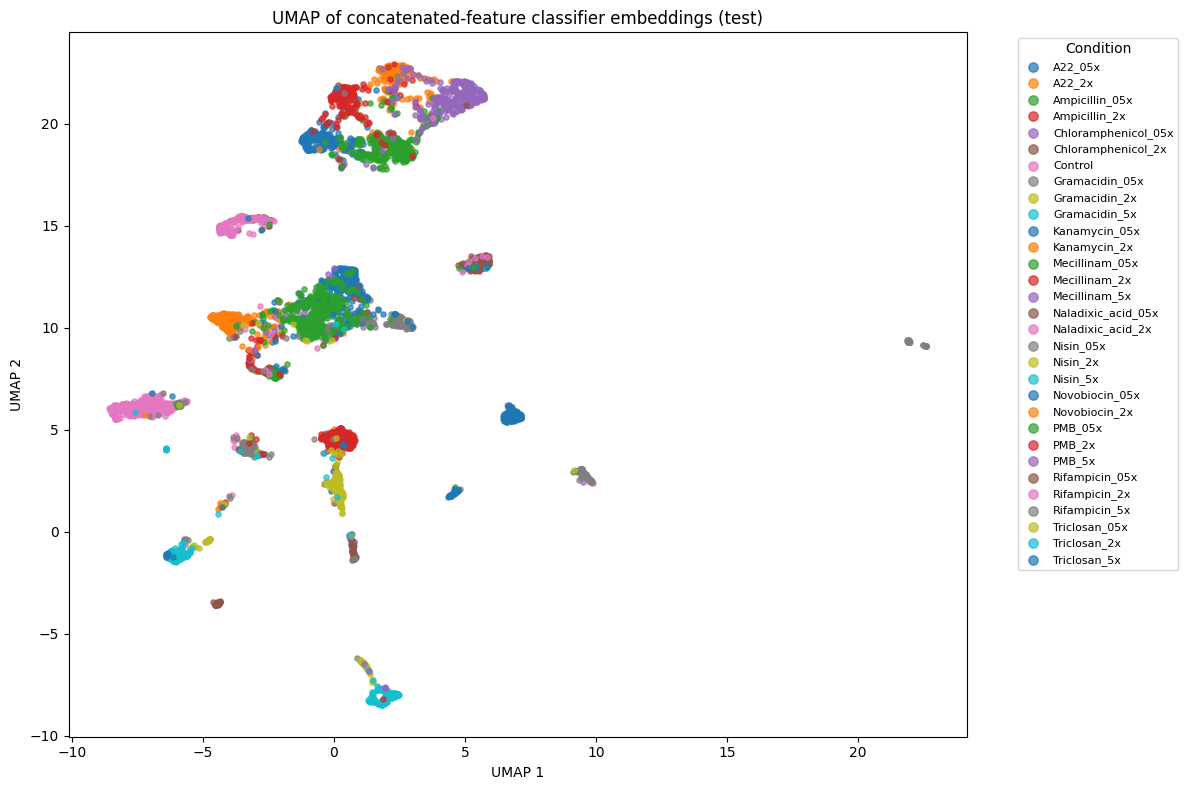

In [61]:
try:
    import umap
    from sklearn.neighbors import NearestNeighbors
except ImportError:
    raise ImportError("Please install umap-learn first: pip install umap-learn")

# Choose which split to visualize: "train", "val", "test", or "all"
UMAP_SOURCE = "test"

# To keep UMAP manageable on large datasets
MAX_UMAP_SAMPLES = 5000

# Whether to standardize the embeddings before UMAP
STANDARDIZE_BEFORE_UMAP = True

# Hide legend if there are too many classes
MAX_LEGEND_CLASSES = 20

RANDOM_SEED = 42


def random_sample_indices(n_samples, max_samples, seed=RANDOM_SEED):
    if n_samples <= max_samples:
        return np.arange(n_samples)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_samples, size=max_samples, replace=False))


def proportional_sample_counts(sizes, max_total):
    total = int(np.sum(sizes))
    if total <= max_total:
        return list(sizes)

    proportions = np.asarray(sizes, dtype=float) / total
    counts = np.floor(proportions * max_total).astype(int)
    counts = np.maximum(counts, 1)

    while counts.sum() > max_total:
        idx = np.argmax(counts)
        if counts[idx] > 1:
            counts[idx] -= 1
        else:
            break

    while counts.sum() < max_total:
        remaining = np.asarray(sizes) - counts
        idx = np.argmax(remaining)
        if remaining[idx] > 0:
            counts[idx] += 1
        else:
            break

    return counts.tolist()


def load_umap_data(results_dir, source="test", max_samples=5000):
    if source not in {"train", "val", "test", "all"}:
        raise ValueError("UMAP_SOURCE must be one of: train, val, test, all")

    if source in {"train", "val", "test"}:
        emb = np.load(results_dir / f"{source}_concat_classifier_embeddings.npy", mmap_mode="r")
        labels = np.load(results_dir / f"{source}_concat_true_names.npy", allow_pickle=True)

        idx = random_sample_indices(len(labels), max_samples)
        X = np.asarray(emb[idx], dtype=np.float32)
        y = np.asarray(labels[idx]).astype(str)
        splits = np.array([source] * len(idx))

        return X, y, splits

    split_names = ["train", "val", "test"]
    sizes = []

    for split in split_names:
        labels = np.load(results_dir / f"{split}_concat_true_names.npy", allow_pickle=True)
        sizes.append(len(labels))

    counts = proportional_sample_counts(sizes, max_samples)

    X_list = []
    y_list = []
    split_list = []

    for split, count in zip(split_names, counts):
        emb = np.load(results_dir / f"{split}_concat_classifier_embeddings.npy", mmap_mode="r")
        labels = np.load(results_dir / f"{split}_concat_true_names.npy", allow_pickle=True)

        idx = random_sample_indices(len(labels), count)
        X_list.append(np.asarray(emb[idx], dtype=np.float32))
        y_list.append(np.asarray(labels[idx]).astype(str))
        split_list.append(np.array([split] * len(idx)))

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    splits = np.concatenate(split_list, axis=0)

    return X, y, splits


def plot_umap_by_label(coords, labels, title):
    labels = np.asarray(labels).astype(str)
    unique_labels = np.unique(labels)

    plt.figure(figsize=(12, 8))

    for label in unique_labels:
        mask = labels == label

        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=14,
            alpha=0.7,
            label=label,   # this creates legend entries
        )

    plt.title(title)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")

    plt.legend(
        title="Condition",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
        markerscale=1.8,
    )

    plt.tight_layout()
    plt.show()


def plot_umap_by_split(coords, splits, title):
    splits = np.asarray(splits)
    unique_splits = np.unique(splits)

    plt.figure(figsize=(10, 8))

    for split in unique_splits:
        mask = splits == split
        plt.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=12,
            alpha=0.7,
            label=str(split),
        )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "umap.png", dpi=300, bbox_inches="tight")
    plt.show()


X_umap, y_umap, split_umap = load_umap_data(
    RESULTS_DIR,
    source=UMAP_SOURCE,
    max_samples=MAX_UMAP_SAMPLES,
)

print("UMAP input shape:", X_umap.shape)
print("Number of labels:", len(np.unique(y_umap)))

if STANDARDIZE_BEFORE_UMAP:
    X_umap = StandardScaler().fit_transform(X_umap)
    print("Applied StandardScaler before UMAP.")


REMOVE_OUTLIERS = True
OUTLIER_CONTAMINATION = 0.05  # remove most extreme 2%

if REMOVE_OUTLIERS:
    detector = IsolationForest(
        contamination=OUTLIER_CONTAMINATION,
        random_state=RANDOM_SEED,
    )

    keep_mask = detector.fit_predict(X_umap) == 1

    print("Before removing outliers:", X_umap.shape)
    print("After removing outliers:", X_umap[keep_mask].shape)
    print("Removed:", np.sum(~keep_mask))

    X_umap = X_umap[keep_mask]
    y_umap = y_umap[keep_mask]
    split_umap = split_umap[keep_mask]

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_SEED,
)

umap_coords = reducer.fit_transform(X_umap)

# Save results
np.save(RESULTS_DIR / f"concat_umap_{UMAP_SOURCE}_coords.npy", umap_coords)

umap_df = pd.DataFrame({
    "split": split_umap,
    "label": y_umap,
    "umap_x": umap_coords[:, 0],
    "umap_y": umap_coords[:, 1],
})
umap_df.to_csv(RESULTS_DIR / f"concat_umap_{UMAP_SOURCE}_coords.csv", index=False)

# Plot by label
plot_umap_by_label(
    umap_coords,
    y_umap,
    title=f"UMAP of concatenated-feature classifier embeddings ({UMAP_SOURCE})",
)

# If using all splits, also plot by split
if UMAP_SOURCE == "all":
    plot_umap_by_split(
        umap_coords,
        split_umap,
        title="UMAP of concatenated-feature classifier embeddings (colored by split)",
    )